---
##### *DSAI3301 Data Analysis & Visualization - 5* 

## *Project #19* - **Medical Insurance Charges Determinants**
### Amanda Haddad - 60306436

##### *Research Question:* Which factors significantly influence medical insurance charges, and how large are their effects?
##### *Methodology:* Inferential Statistical Analysis
##### *Domain:* Healthcare & Insurance
##### *Dataset Link:* https://www.kaggle.com/datasets/mirichoi0218/insurance
---



### 1. Libraries & Dataset Setup
---

In [ ]:
# environment setup
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn jupyter

In [3]:
# imports & dataset loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 2. Dataset Description
---

In [ ]:
# column data types
df.dtypes

# all approporiate, no conversions needed

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
# statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# rows and columns
df.shape

(1338, 7)

### 3. Data Cleaning
---

In [ ]:
# check for missing/null values
df.isnull().sum()

# no missing/null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# check for duplicates
df.duplicated().sum()

np.int64(1)

In [ ]:
# remove the 1 duplicate row found, then check shape
df = df.drop_duplicates()
df.shape       # Expected: (1337, 7)

(1337, 7)

In [ ]:
# categorical columns:
# check expected values (no typos or unexpected entries)
print(df['sex'].unique())      # Expected: ['male' 'female']
print(df['smoker'].unique())   # Expected: ['yes' 'no']
print(df['region'].unique())   # Expected: 4 regions

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


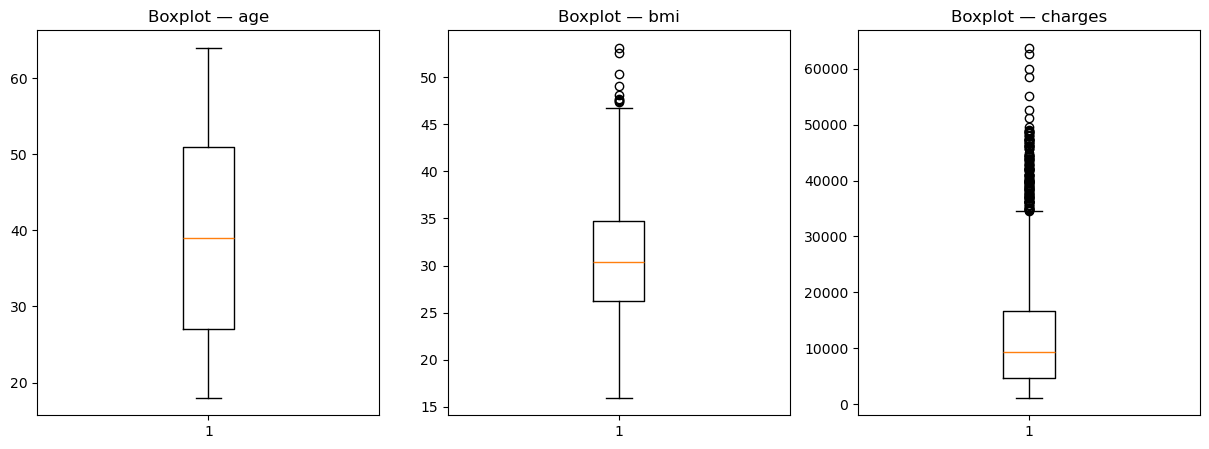

In [ ]:
# numerical columns:
# plot to visually detect outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot — {col}')

plt.show()

In [ ]:
# quanitfy outliers using IQR method
for col in ['age', 'bmi', 'charges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (below {lower:.1f} or above {upper:.1f})")

# outliers detected in bmi and charges

age: 0 outliers (below -9.0 or above 87.0)
bmi: 9 outliers (below 13.7 or above 47.3)
charges: 139 outliers (below -13120.7 or above 34524.8)


In [ ]:
# investigate bmi outliers' validity
print(f"Max BMI: {df['bmi'].max()}")
print(f"Min BMI: {df['bmi'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max BMI: 53.13
Min BMI: 15.96


In [ ]:
# investigate charges outliers' validity
print(f"Max charges: {df['charges'].max()}")
print(f"Min charges: {df['charges'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max charges: 63770.42801
Min charges: 1121.8739


### Data Cleaning Summary

| Check | Finding | Action Taken |
|---|---|---|
| Missing values | 0 across all columns | None required |
| Duplicate rows | 1 duplicate row found | Removed row |
| Categorical validity | All values match expected categories | None required |
| Numeric ranges | BMI and Charges contain outliers (9 & 139) | Extra investigation |
| BMI outliers | All values are valid | Preserved outliers |
| Charges outliers | All values are valid | Preserved outliers |


#### Outlier Decisions

**BMI**
- Max value is 53.13, min is 15.96
- No values below 10 or above 100 were found
- High BMI values (> 40) represent severe obesity (Class 3)
- Removing the clinically justified values would  weaken the BMI–charges relationship to be tested

**Charges**
- Max is 63770, min is 1,121 (no zero or negative values exist in the data)
- Really high values represent real high-cost cases, not errors
- Removing them would bias the regression against the patients that drive costs

#### Dataset is now clean and ready for analysis.
---


### 4. Data Visualization
---

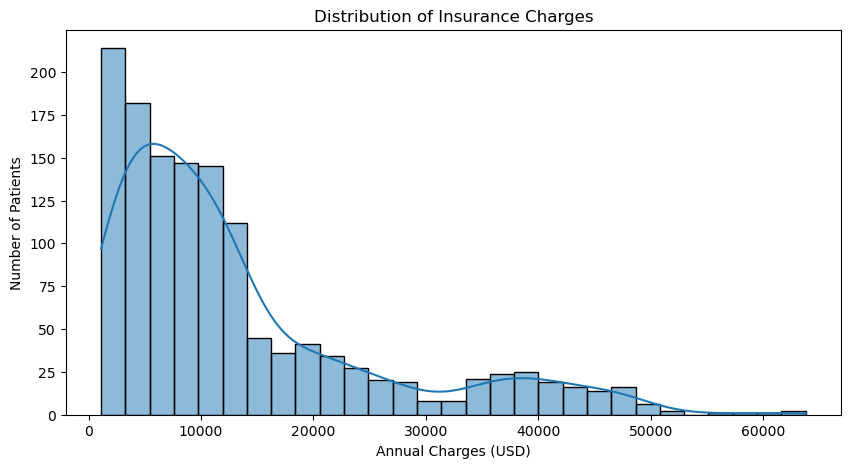

In [ ]:
# Plot 1: Distribution of charges (target variable)
plt.figure(figsize=(10,5))
sns.histplot(df['charges'], kde=True)

plt.title('Distribution of Insurance Charges')
plt.xlabel('Annual Charges (USD)')
plt.ylabel('Number of Patients')

plt.show()

**Observations**: The distribution of charges is right-skewed, with most patients paying between 
$1,000 and $15,000. A secondary bump is visible around $30,000–$50,000, 
likely driven by high-risk patients such as smokers and obese individuals.

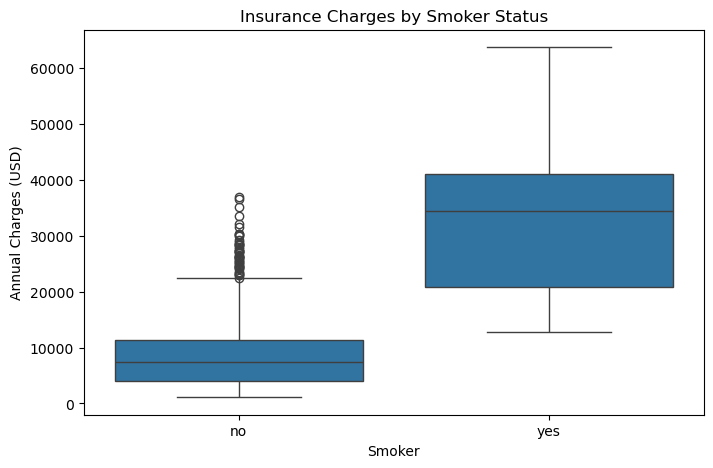

In [ ]:
# Plot 2: Insurance Charges by Smoker Status (strongest predictor)
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, order=['no', 'yes'])

plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')                 # categorical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.show()

**Observations**: Smokers pay dramatically more than non-smokers. The difference in median charge for smokers 
is roughly $25,000. This suggests smoker status will be the strongest predictor in the regression model.

Most following plots are colored by smoker status for further examination.

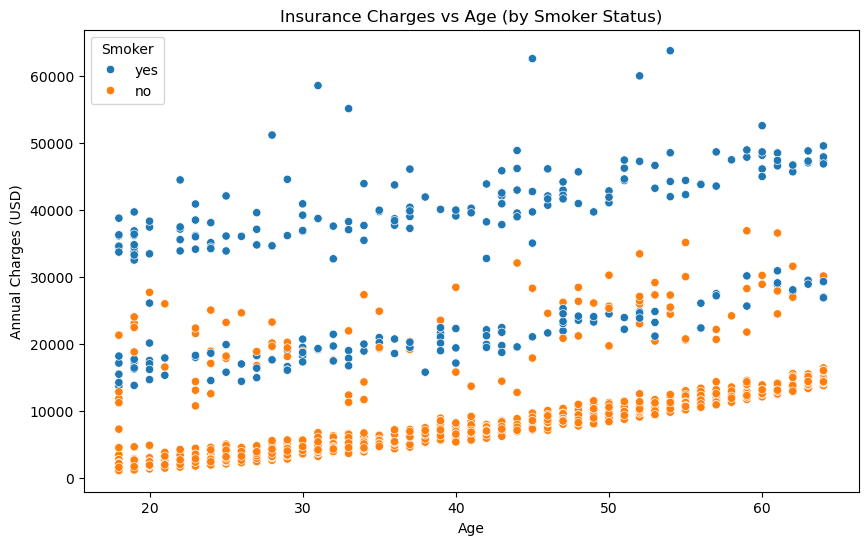

In [ ]:
# Plot 3: Insurance Charges vs Age (secondary predictor)
plt.figure(figsize=(10, 6))

sns.scatterplot(x='age', y='charges', hue='smoker', data=df)

plt.title('Insurance Charges vs Age (by Smoker Status)')
plt.xlabel('Age')                    # numerical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.legend(title='Smoker', loc='upper left')

plt.show()

# Observations: charges increase with age

**Observations**: Three distinct bands are visible. The bottom band represents non-smokers, 
the top band represents smokers, and charges increase with age within both groups. 
This confirms age as a positive predictor of charges regardless of smoking status.

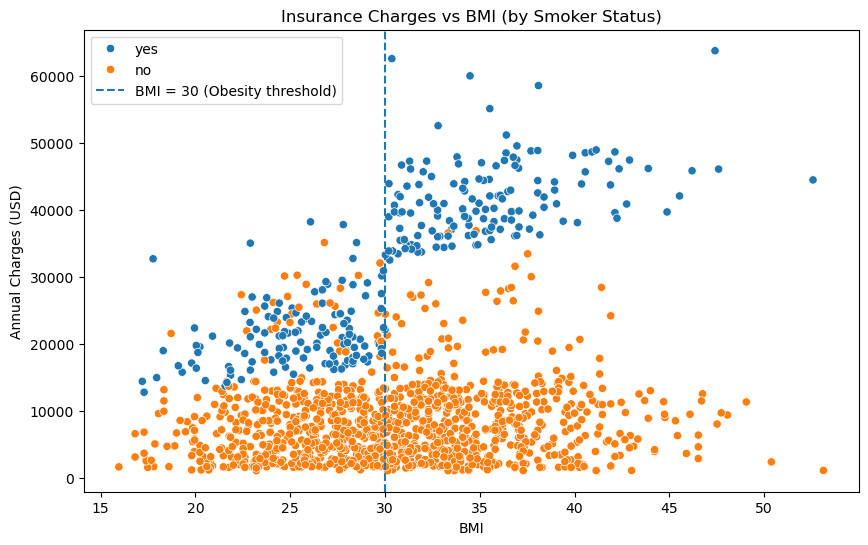

In [ ]:
# Plot 4: Insurance Charges vs BMI (colored by smoker)
plt.figure(figsize=(10, 6))

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.axvline(x=30, color='black', linestyle='--', label='BMI = 30 (Obesity threshold)')

plt.title('Insurance Charges vs BMI (by Smoker Status)')
plt.xlabel('BMI')                     # numerical
plt.ylabel('Annual Charges (USD)')    # numerical
plt.legend(title='', loc='upper left')

plt.show()

**Observations**: For non-smokers, BMI has a modest effect on charges. For smokers however, 
charges increase sharply once BMI crosses 30 (the obesity threshold), suggesting 
a dangerous interaction between smoking and obesity that drives costs significantly higher.

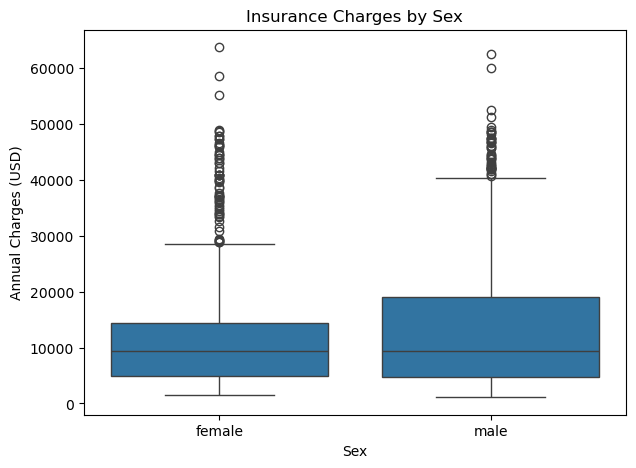

In [57]:
# Plot 5: Insurance Charges by Sex
plt.figure(figsize=(7, 5))

sns.boxplot(x='sex', y='charges', data=df)

plt.title('Insurance Charges by Sex')
plt.xlabel('Sex')                    # categorical
plt.ylabel('Annual Charges (USD)')   # numerical

plt.show()

**Observations**: Other than Males having a higher Q3, distributions between both overlap heavily. Sex is not expected to be a strong 
predictor of charges, though this will be confirmed statistically in Phase 4.

C:\Users\amand\AppData\Local\Temp\ipykernel_30236\2462474567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='region', y='charges', data=df, palette='muted')


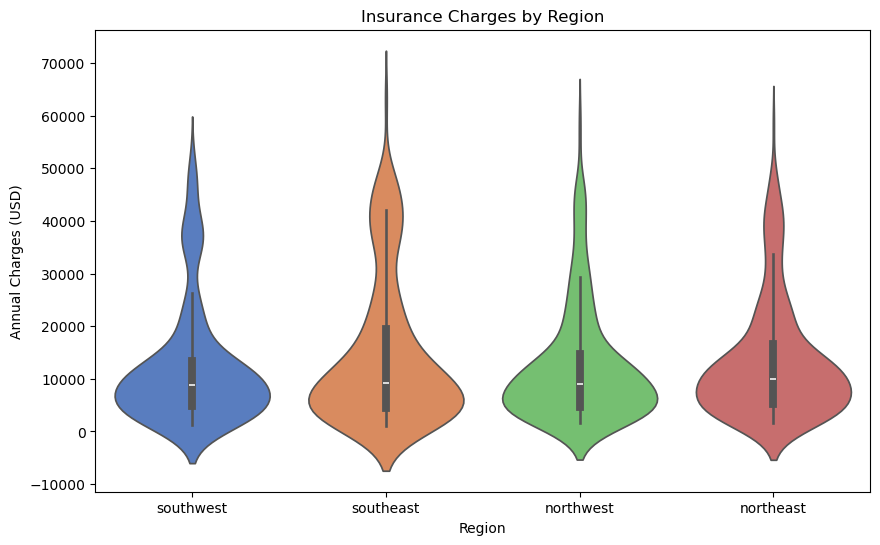

In [ ]:
# Plot 6: Insurance Charges by Region
plt.figure(figsize=(10, 6))

sns.violinplot(x='region', y='charges', data=df, palette='muted')

plt.title('Insurance Charges by Region')
plt.xlabel('Region')                  # categorical
plt.ylabel('Annual Charges (USD)')    # numerical

plt.show()

**Observations**: Charges are very similar across all four regions. 
Despite the reasonable expectation that geography would affect costs, 
region appears to have little influence on charges in this dataset.

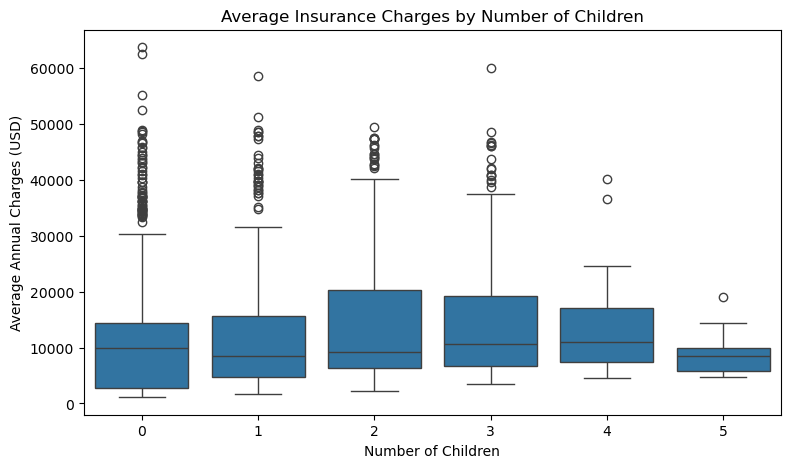

In [58]:
# Plot 6: Insurance Charges by Number of Children

plt.figure(figsize=(9, 5))

sns.boxplot(x='children', y='charges', data=df)

plt.title('Average Insurance Charges by Number of Children')
plt.xlabel('Number of Children')         
plt.ylabel('Average Annual Charges (USD)')   

plt.show()

# Observations: no clear relationship between number of children and charges

**Observations**: There is no consistent upward trend in charges as the number of children increases. 
Contrary to the assumption that more children would drive higher costs, 
children appear to have little effect on charges in this dataset.

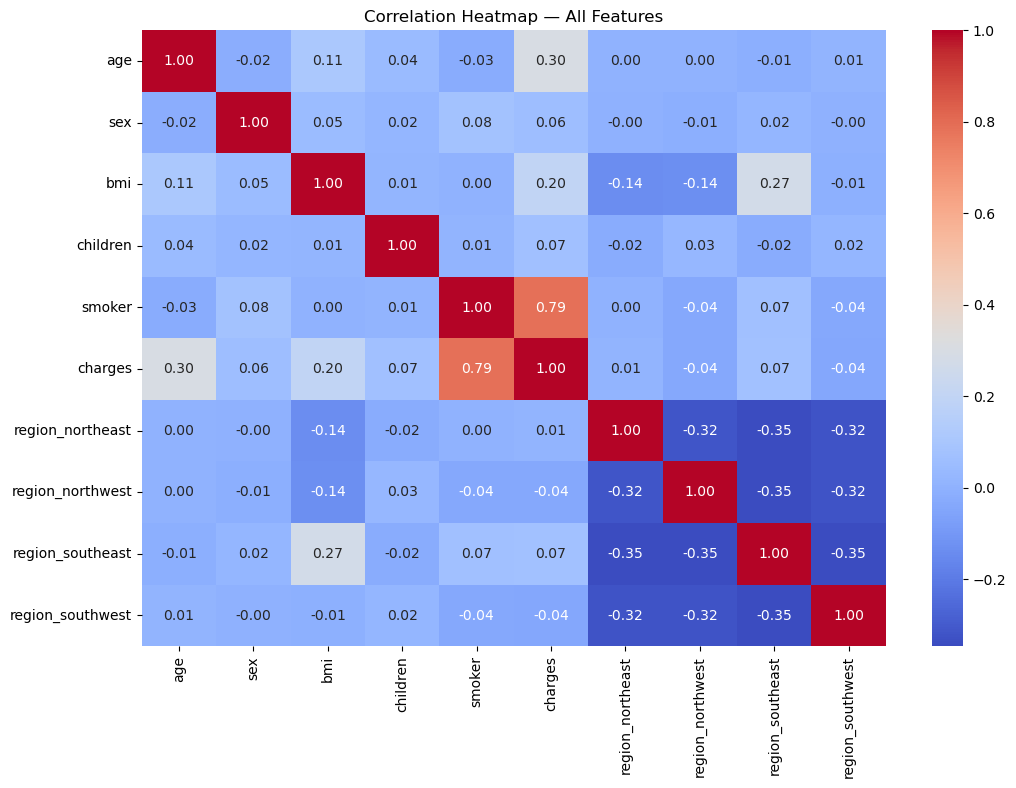

In [ ]:
# Plot 8: Correlation heatmap
df_encoded = df.copy()

# Map categoricals to 0/1
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['region'])

plt.figure(figsize=(12, 8))

sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap — All Features')
plt.show()

### Visualization Decisions Based on Correlation

From the heatmap:
- `smoker` (r ≈ 0.79) → strongest predictor
- `age` (r ≈ 0.30) → moderate predictor
- `bmi` (r ≈ 0.20) → moderate predictor
- `region` (r ≈ 0.01–0.04) → insignificant
- `children` (r ≈ 0.07) → insignificant
- `sex` (r ≈ 0.06) → insignificant
---

### 5. Inferential Statistical Analysis
---

#### Test #1: One-Way ANOVA (Charges vs Sex)

Comparing the means of charges (continuous) and sex (binary categorical). This answers whether sex is a significant driver of charges.